Found 39 files
Years: [1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Unique shapes: {(772, 957)}
Unique CRS:    {'EPSG:32645'}


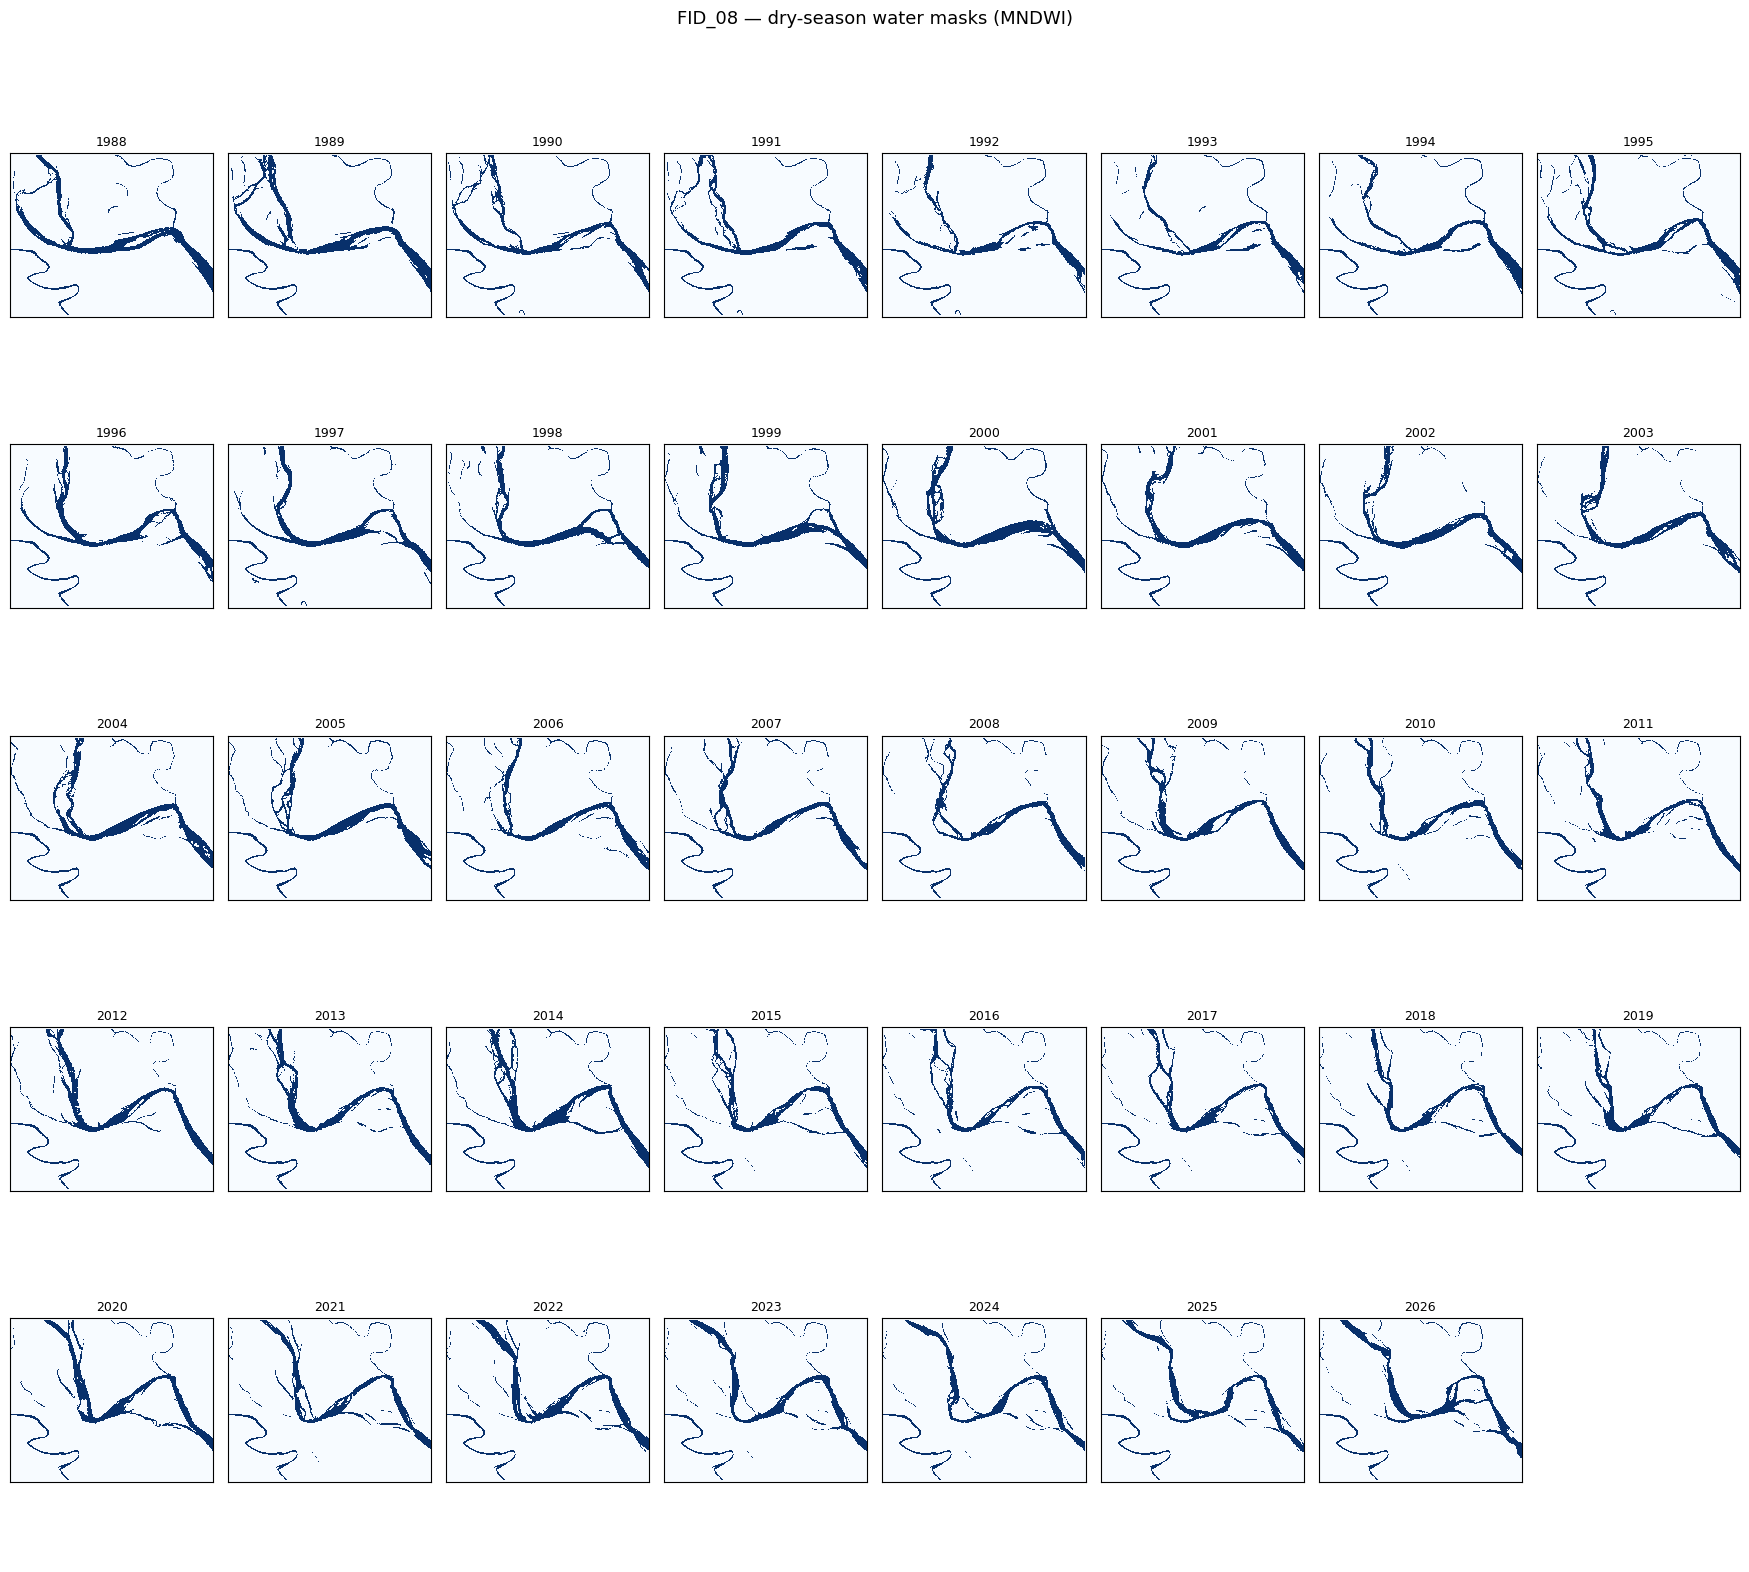

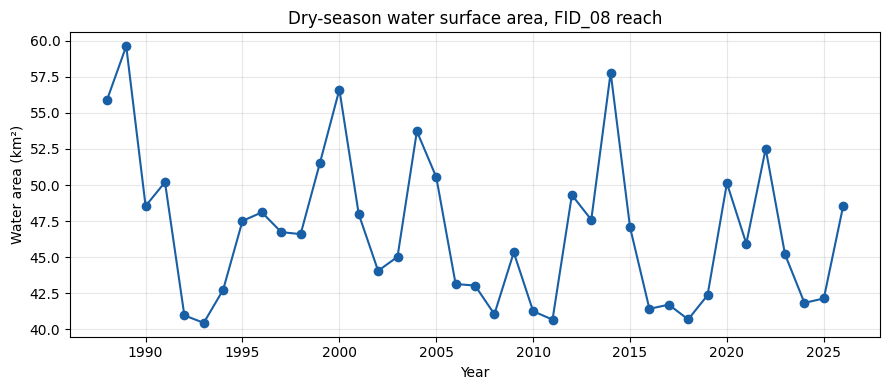

In [1]:
"""
Load & plot yearly binary water masks (FID_08, 1988-2026)
Requires: rasterio, numpy, matplotlib   (pip install rasterio matplotlib)
"""

import glob, os, re
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Discover files
# ------------------------------------------------------------------
FOLDER = r"E:\MSc RBE\VS_Code\Pytorch_ENV\FID_08_WaterMasks"
pattern = os.path.join(FOLDER, "FID_08_*_LS_*_MNDWI_water_mask_filtered_1000px.tif")

files = glob.glob(pattern)
print(f"Found {len(files)} files")

# extract year from filename, e.g. FID_08_1988_LS_05_...
def get_year(path):
    m = re.search(r"FID_08_(\d{4})_LS", os.path.basename(path))
    return int(m.group(1)) if m else None

files = sorted([f for f in files if get_year(f)], key=get_year)
years = [get_year(f) for f in files]
print("Years:", years)

# ------------------------------------------------------------------
# 2. Load masks
# ------------------------------------------------------------------
masks, profiles = {}, {}
for f, yr in zip(files, years):
    with rasterio.open(f) as src:
        arr = src.read(1)
        masks[yr] = (arr > 0).astype(np.uint8)   # force binary 0/1
        profiles[yr] = {"transform": src.transform,
                        "crs": src.crs,
                        "res": src.res,
                        "shape": arr.shape}

# quick consistency check — all years should share grid & CRS
shapes = {p["shape"] for p in profiles.values()}
crss   = {str(p["crs"]) for p in profiles.values()}
print("Unique shapes:", shapes)
print("Unique CRS:   ", crss)

# ------------------------------------------------------------------
# 3. Panel grid: planform time series
# ------------------------------------------------------------------
n = len(years)
ncols = 8
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 3.2))
axes = np.atleast_2d(axes)

for ax, yr in zip(axes.flat, years):
    ax.imshow(masks[yr], cmap="Blues", interpolation="nearest")
    ax.set_title(str(yr), fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[n:]:
    ax.axis("off")

fig.suptitle("FID_08 — dry-season water masks (MNDWI)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(FOLDER, "mask_timeseries_panels.png"), dpi=200)
plt.show()

# ------------------------------------------------------------------
# 4. Water area time series (first quantitative look)
# ------------------------------------------------------------------
areas_km2 = []
for yr in years:
    px_area = abs(profiles[yr]["res"][0] * profiles[yr]["res"][1])  # m2 if projected CRS
    areas_km2.append(masks[yr].sum() * px_area / 1e6)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(years, areas_km2, "o-", color="#185FA5")
ax.set_xlabel("Year"); ax.set_ylabel("Water area (km²)")
ax.set_title("Dry-season water surface area, FID_08 reach")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join(FOLDER, "water_area_timeseries.png"), dpi=200)
plt.show()

In [9]:
"""
Generate channel centerlines (CL) from binary water masks
FID_08, 1988-2026 — export as GeoJSON (WGS84)

Requires:
pip install rasterio numpy matplotlib scikit-image sknw networkx shapely geopandas
"""

import glob, os, re
import numpy as np
import rasterio
import networkx as nx
import sknw
from skimage.morphology import (skeletonize, remove_small_objects,
                                remove_small_holes, binary_closing, disk)
from shapely.geometry import LineString
import geopandas as gpd

# ------------------------------------------------------------------
# Config
# ------------------------------------------------------------------
FOLDER  = r"G:\Cahnnel Complexity Ganges\Cahnnel Mask\Ganges_Binary_Mask"
OUT_DIR = os.path.join(FOLDER, "centerlines")
os.makedirs(OUT_DIR, exist_ok=True)

MIN_OBJ_PX   = 1000   # remove water patches smaller than this (px)
MIN_HOLE_PX  = 200    # fill small sand specks inside channels (px)
CLOSING_RAD  = 1      # px; bridges 1-px gaps in the mask (0 = disable)
SPUR_LEN_PX  = 25     # prune dead-end edges shorter than this (px)
MIN_BRANCH_M = 500    # drop isolated fragments shorter than this (m)
UTM_EPSG     = 32645  # used only if raster CRS is geographic (32646 if east of 90E)

# ------------------------------------------------------------------
# File discovery
# ------------------------------------------------------------------
def get_year(p):
    m = re.search(r"^(\d{4})_.*_Ganges_Binary_Mask\.tif$", os.path.basename(p))
    return int(m.group(1)) if m else None

files = sorted(
    [f for f in glob.glob(os.path.join(FOLDER, "*_Ganges_Binary_Mask.tif"))
     if get_year(f)],
    key=get_year)
years = [get_year(f) for f in files]
print(f"{len(files)} masks: {years[0]}-{years[-1]}")

# ------------------------------------------------------------------
# Per-year processing
# ------------------------------------------------------------------
summary = []

for f, yr in zip(files, years):
    with rasterio.open(f) as src:
        mask = (src.read(1) > 0)
        transform, crs = src.transform, src.crs

    # ---- 1. Clean mask --------------------------------------------
    if CLOSING_RAD > 0:
        mask = binary_closing(mask, disk(CLOSING_RAD))
    mask = remove_small_objects(mask, min_size=MIN_OBJ_PX)
    mask = remove_small_holes(mask, area_threshold=MIN_HOLE_PX)

    # ---- 2. Skeletonize --------------------------------------------
    skel = skeletonize(mask)

    # ---- 3. Build graph + prune spurs iteratively -------------------
    G = sknw.build_sknw(skel, full = True)
    changed = True
    while changed:
        changed = False
        for u, v in list(G.edges()):
            if u == v:                                   # self-loop artifacts
                G.remove_edge(u, v); changed = True; continue
            if (G.degree[u] == 1 or G.degree[v] == 1) and G[u][v]['weight'] < SPUR_LEN_PX:
                G.remove_edge(u, v); changed = True
        G.remove_nodes_from(list(nx.isolates(G)))

    # ---- 4. Edges -> geographic LineStrings -------------------------
    lines = []
    for u, v in G.edges():
        pts = G[u][v]['pts']                             # (row, col) array
        if len(pts) < 2:
            continue
        coords = [transform * (int(c), int(r)) for r, c in pts]
        lines.append(LineString(coords))

    if not lines:
        print(f"{yr}: no centerlines extracted - check mask!")
        continue

    gdf = gpd.GeoDataFrame({"year": [yr] * len(lines)}, geometry=lines, crs=crs)

    # ---- 5. Lengths in meters (guard against geographic CRS) --------
    if crs is not None and crs.is_projected:
        gdf["length_m"] = gdf.length
    else:
        gdf["length_m"] = gdf.to_crs(epsg=UTM_EPSG).length

    gdf = gdf[gdf.length_m > MIN_BRANCH_M].reset_index(drop=True)

    if gdf.empty:
        print(f"{yr}: all segments below {MIN_BRANCH_M} m - check mask!")
        continue

    # ---- 6. Export GeoJSON (WGS84 per spec) -------------------------
    out_geojson = os.path.join(OUT_DIR, f"CL_FID08_{yr}.geojson")
    gdf.to_crs(epsg=4326).to_file(out_geojson, driver="GeoJSON")

    total_km = gdf.length_m.sum() / 1000
    summary.append((yr, len(gdf), total_km))
    print(f"{yr}: {len(gdf)} segments, {total_km:.1f} km -> {os.path.basename(out_geojson)}")

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
print("\nYear  Segments  Total_km")
for yr, n, km in summary:
    print(f"{yr}   {n:5d}    {km:8.1f}")

38 masks: 1988-2025
1988: 774 segments, 1417.5 km -> CL_FID08_1988.geojson
1989: 862 segments, 1564.1 km -> CL_FID08_1989.geojson
1990: 1126 segments, 1836.2 km -> CL_FID08_1990.geojson
1991: 1080 segments, 1632.9 km -> CL_FID08_1991.geojson
1992: 3332 segments, 3752.4 km -> CL_FID08_1992.geojson
1993: 926 segments, 1555.3 km -> CL_FID08_1993.geojson
1994: 417 segments, 819.2 km -> CL_FID08_1994.geojson
1995: 902 segments, 1528.8 km -> CL_FID08_1995.geojson
1996: 1120 segments, 1909.8 km -> CL_FID08_1996.geojson
1997: 803 segments, 1447.1 km -> CL_FID08_1997.geojson
1998: 1231 segments, 1973.2 km -> CL_FID08_1998.geojson
1999: 845 segments, 1487.0 km -> CL_FID08_1999.geojson
2000: 1079 segments, 1817.9 km -> CL_FID08_2000.geojson
2001: 993 segments, 1683.7 km -> CL_FID08_2001.geojson
2002: 991 segments, 1694.2 km -> CL_FID08_2002.geojson
2003: 817 segments, 1492.4 km -> CL_FID08_2003.geojson
2004: 1112 segments, 1784.6 km -> CL_FID08_2004.geojson
2005: 1292 segments, 1955.6 km -> CL_FI